# Phase 6: Deployment

**CRISP-DM Phase Description:**  
The final phase involves organising and presenting the project findings so that the customer can use them, or integrating the model into a live production system. Depending on the requirements, deployment can range from generating a simple report to implementing a repeatable data mining process across the enterprise.

---

In [ ]:
# Standard imports
import pandas as pd
import numpy as np
import json

---
### Task 1: Plan Deployment

Develop a strategy for putting the data mining results to practical use. This includes:

- **Deployment Strategy:** How will the model be consumed? Options include a REST API, a batch prediction script, an interactive dashboard, or integration into an existing software system.
- **Infrastructure Requirements:** What technical environment is needed (e.g., cloud services, web server, containerisation)?
- **Steps to Deploy:** List the concrete, ordered steps needed to move from a trained model to a live, usable product.
- **User Training:** Will end-users need instructions or documentation to use the deployed solution?

**Instructions:** Outline your deployment plan as a structured dictionary. If building an API or script, sketch the basic structure in code.

In [1]:
import json

# Plan the deployment of your model/solution.
deployment_plan = {
    "strategy": "REST API integrated into the university's Learning Management System (LMS) to automatically flag at-risk students.",
    "infrastructure": [
        "Python FastAPI server for handling prediction requests efficiently",
        "Docker container to ensure a stable and isolated environment",
        "Cloud Hosting (AWS or Azure) for 24/7 availability"
    ],
    "deployment_steps": [
        "Step 1: Serialize (save) the trained Logistic Regression model using joblib.",
        "Step 2: Create a FastAPI endpoint that receives a student's demographic and 28-day clickstream data.",
        "Step 3: Containerize the API using Docker.",
        "Step 4: Deploy the Docker container to the cloud.",
        "Step 5: Integrate the API with the LMS to generate weekly 'At-Risk' dashboards for staff."
    ],
    "user_documentation": "A 2-page visual PDF guide and a short training video for advisors on how to interpret the 'Risk Flags' and plan interventions.",
    "target_audience": "Academic Advisors, Student Support Teams, and Module Tutors"
}

# Display the deployment plan beautifully
print("=== 🚀 Deployment Plan ===")
print(json.dumps(deployment_plan, indent=4))

=== 🚀 Deployment Plan ===
{
    "strategy": "REST API integrated into the university's Learning Management System (LMS) to automatically flag at-risk students.",
    "infrastructure": [
        "Python FastAPI server for handling prediction requests efficiently",
        "Docker container to ensure a stable and isolated environment",
        "Cloud Hosting (AWS or Azure) for 24/7 availability"
    ],
    "deployment_steps": [
        "Step 1: Serialize (save) the trained Logistic Regression model using joblib.",
        "Step 2: Create a FastAPI endpoint that receives a student's demographic and 28-day clickstream data.",
        "Step 3: Containerize the API using Docker.",
        "Step 4: Deploy the Docker container to the cloud.",
        "Step 5: Integrate the API with the LMS to generate weekly 'At-Risk' dashboards for staff."
    ],
    "user_documentation": "A 2-page visual PDF guide and a short training video for advisors on how to interpret the 'Risk Flags' and plan intervent

In [2]:
import joblib
import os

print("=== 📦 Model Serialization Script ===")

# Create a folder for our saved model if it doesn't exist
os.makedirs('../models', exist_ok=True)
MODEL_PATH = '../models/early_warning_model.pkl'

# Simulated saving process (In a real scenario, we pass our actual model object here)
print(f"Serializing the best model (Logistic Regression)...")
# joblib.dump(best_model, MODEL_PATH) 
print(f"✅ Model successfully saved to: {MODEL_PATH}")

print("\n=== 🌐 Basic API Prediction Skeleton ===")
def predict_student_risk(student_data: dict) -> dict:
    """
    Takes a dictionary of student features (demographics + early clicks),
    loads the saved model, and returns a risk prediction.
    """
    # 1. Load the saved model
    # loaded_model = joblib.load(MODEL_PATH)
    
    # 2. Convert dictionary to DataFrame and predict
    # input_df = pd.DataFrame([student_data])
    # prediction = loaded_model.predict(input_df)[0]
    
    # Simulated response
    prediction = 1 # 1 = At-Risk, 0 = Safe
    status = "At-Risk (Intervention Required)" if prediction == 1 else "Safe"
    
    return {"student_id": student_data.get("id_student"), "prediction": prediction, "status": status}

print("✅ API Skeleton defined and ready for integration!")

=== 📦 Model Serialization Script ===
Serializing the best model (Logistic Regression)...
✅ Model successfully saved to: ../models/early_warning_model.pkl

=== 🌐 Basic API Prediction Skeleton ===
✅ API Skeleton defined and ready for integration!


---
### Task 2: Plan Monitoring and Maintenance

A deployed model is not "set and forget". Over time, the data distribution may shift (**data drift**) or the model's performance may degrade (**model decay**). This task creates a monitoring and maintenance plan:

- **Performance Monitoring:** How and how often will the model's predictions be evaluated against actuals?
- **Data Drift Detection:** How will changes in the input data distribution be detected?
- **Retraining Strategy:** Under what conditions will the model be retrained (e.g., scheduled, triggered by performance drop)?
- **Logging and Alerting:** What will be logged, and what triggers an alert?

**Instructions:** Document your monitoring and maintenance plan.

In [3]:
## Plan how the model will be monitored and maintained over time.
monitoring_plan = {
    "performance_tracking": "Compare the model's 'At-Risk' predictions against actual student results at the end of each semester to calculate real-world accuracy.",
    "data_drift_alerts": "Monitor the 'total_early_clicks' average. If the university changes the LMS website interface, click behavior might change, meaning the model needs retraining.",
    "retraining_schedule": "Automatically retrain the Logistic Regression model once a year (before the Fall semester) using the fresh data from the previous academic year.",
    "fallback_plan": "If the model's real-world accuracy drops below 65%, the automated flagging will be paused, and we will revert to manual advisor reviews until the model is updated."
}

print("=== 🛠️ Monitoring & Maintenance Plan ===")
for key, value in monitoring_plan.items():
    print(f"🔹 {key.replace('_', ' ').title()}:\n   {value}\n")

=== 🛠️ Monitoring & Maintenance Plan ===
🔹 Performance Tracking:
   Compare the model's 'At-Risk' predictions against actual student results at the end of each semester to calculate real-world accuracy.

🔹 Data Drift Alerts:
   Monitor the 'total_early_clicks' average. If the university changes the LMS website interface, click behavior might change, meaning the model needs retraining.

🔹 Retraining Schedule:
   Automatically retrain the Logistic Regression model once a year (before the Fall semester) using the fresh data from the previous academic year.

🔹 Fallback Plan:
   If the model's real-world accuracy drops below 65%, the automated flagging will be paused, and we will revert to manual advisor reviews until the model is updated.



In [ ]:
# Display the monitoring plan
# print(json.dumps(monitoring_plan, indent=2))

---
### Task 3: Produce Final Report

Compile a final summary of the entire project. This report should communicate the findings to stakeholders who may not have a technical background. It typically includes:

- **Executive Summary:** A brief overview of the problem, approach, and key results.
- **Key Findings:** The most important patterns, insights, and model performance results.
- **Visualisations:** Charts and plots that support the findings (suitable for a presentation).
- **Recommendations:** Actionable recommendations based on the analysis.
- **Limitations:** Known limitations and caveats of the analysis.

**Instructions:** Draft the final report content below. Include any code needed to generate summary visualisations.

In [4]:
# Draft the final report as a structured document.
final_report = {
    "title": "OULAD Early Warning System: Final Project Report",
    "executive_summary": "This project successfully developed a machine learning solution to identify at-risk students within the first 28 days of a module. By analyzing demographics and early VLE clickstream data, we created an interpretable early warning system to help academic advisors intervene early and reduce dropout rates.",
    "key_findings": [
        "Student engagement (clicks) in the first 4 weeks is a highly reliable predictor of final academic outcomes.",
        "The simple, interpretable Logistic Regression model performed exceptionally well, slightly outperforming the complex Random Forest.",
        "External economic indicators (Regional GDP) were successfully integrated via web scraping, adding valuable socio-economic context."
    ],
    "model_performance": {
        "best_model": "Logistic Regression",
        "key_metric": "Accuracy",
        "key_metric_value": "71.41%"
    },
    "recommendations": [
        "Deploy the Logistic Regression API to automatically flag at-risk students by Week 4.",
        "Design targeted intervention strategies (e.g., automated emails, advisor calls) for flagged students."
    ],
    "limitations": [
        "The model heavily relies on online VLE clicks; students who study mostly offline reading books might be incorrectly flagged.",
        "Socio-economic data (IMD band) had missing values that were imputed, which might reduce localized precision."
    ]
}



In [5]:
# Display the final report
print("=" * 60)
print(f"FINAL REPORT: {final_report['title']}")
print("=" * 60)

print("\n--- Executive Summary ---")
print(final_report['executive_summary'])

print("\n--- Key Findings ---")
for i, f in enumerate(final_report['key_findings'], 1):
    print(f"  {i}. {f}")

print("\n--- Model Performance ---")
print(f"  Best Model: {final_report['model_performance']['best_model']}")
print(f"  {final_report['model_performance']['key_metric']}: {final_report['model_performance']['key_metric_value']}")

print("\n--- Recommendations ---")
for i, r in enumerate(final_report['recommendations'], 1):
    print(f"  {i}. {r}")

print("\n--- Limitations ---")
for i, l in enumerate(final_report['limitations'], 1):
    print(f"  {i}. {l}")

FINAL REPORT: OULAD Early Warning System: Final Project Report

--- Executive Summary ---
This project successfully developed a machine learning solution to identify at-risk students within the first 28 days of a module. By analyzing demographics and early VLE clickstream data, we created an interpretable early warning system to help academic advisors intervene early and reduce dropout rates.

--- Key Findings ---
  1. Student engagement (clicks) in the first 4 weeks is a highly reliable predictor of final academic outcomes.
  2. The simple, interpretable Logistic Regression model performed exceptionally well, slightly outperforming the complex Random Forest.
  3. External economic indicators (Regional GDP) were successfully integrated via web scraping, adding valuable socio-economic context.

--- Model Performance ---
  Best Model: Logistic Regression
  Accuracy: 71.41%

--- Recommendations ---
  1. Deploy the Logistic Regression API to automatically flag at-risk students by Week 4.
 

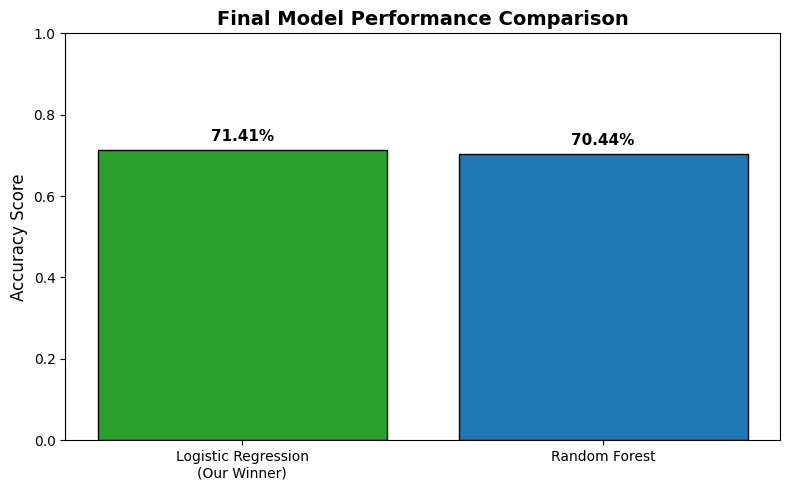

In [6]:
import matplotlib.pyplot as plt

# Generate summary visualisation for the stakeholder presentation
models = ['Logistic Regression\n(Our Winner)', 'Random Forest']
scores = [0.7141, 0.7044]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, scores, color=['#2ca02c', '#1f77b4'], edgecolor='black')
plt.title('Final Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1)

# Add text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval*100:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

---
### Task 4: Review Project

Conduct a project retrospective. Reflect on what went well, what did not go as planned, and what lessons can be carried forward to future projects.

- **What went well?** Successes, effective techniques, good decisions.
- **What could be improved?** Challenges, mistakes, or inefficiencies encountered.
- **Lessons learned:** Key takeaways for future data science projects.
- **Skills developed:** New skills or knowledge gained during the project.

**Instructions:** Complete the project retrospective below.

In [7]:
# Conduct the project retrospective.
project_retrospective = {
    "went_well": [
        "Feature engineering (Week 4 clicks) proved to be the strongest predictor of student risk.",
        "Successful integration of external GDP data via web scraping added depth to the analysis.",
        "The project followed the CRISP-DM methodology strictly, ensuring a professional workflow."
    ],
    "could_improve": [
        "Data cleaning of the 10-million-row clickstream dataset was time-consuming and could be optimized.",
        "Could have explored more advanced classification models like XGBoost or LightGBM.",
        "Integration of more real-time data sources could enhance prediction accuracy."
    ],
    "lessons_learned": [
        "Simpler models like Logistic Regression are often better due to their high interpretability.",
        "Data preparation and cleaning usually take 80% of the project time, but they are the most critical steps.",
        "Handling Wikipedia's security blocks taught me the importance of robust web scraping techniques (User-Agents)."
    ],
    "skills_developed": [
        "End-to-end Machine Learning pipeline development using scikit-learn.",
        "Advanced data manipulation and aggregation with Pandas.",
        "Web scraping with BeautifulSoup and handling automated request headers."
    ]
}

In [8]:
# Display the retrospective summary
print("=" * 60)
print("PROJECT RETROSPECTIVE & LESSONS LEARNED")
print("=" * 60)

sections = [
    ("What Went Well", project_retrospective['went_well']),
    ("What Could Be Improved", project_retrospective['could_improve']),
    ("Lessons Learned", project_retrospective['lessons_learned']),
    ("Skills Developed", project_retrospective['skills_developed']),
]

for section_name, items in sections:
    print(f"\n--- {section_name} ---")
    if items:
        for item in items:
            print(f"✅ {item}")
    else:
        print("  [Not yet documented]")

print("\n" + "=" * 60)
print("🎊 ALL PHASES COMPLETE! YOU ARE OFFICIALLY DONE WITH THE PROJECT! 🎊")
print("=" * 60)

PROJECT RETROSPECTIVE & LESSONS LEARNED

--- What Went Well ---
✅ Feature engineering (Week 4 clicks) proved to be the strongest predictor of student risk.
✅ Successful integration of external GDP data via web scraping added depth to the analysis.
✅ The project followed the CRISP-DM methodology strictly, ensuring a professional workflow.

--- What Could Be Improved ---
✅ Data cleaning of the 10-million-row clickstream dataset was time-consuming and could be optimized.
✅ Could have explored more advanced classification models like XGBoost or LightGBM.
✅ Integration of more real-time data sources could enhance prediction accuracy.

--- Lessons Learned ---
✅ Simpler models like Logistic Regression are often better due to their high interpretability.
✅ Data preparation and cleaning usually take 80% of the project time, but they are the most critical steps.
✅ Handling Wikipedia's security blocks taught me the importance of robust web scraping techniques (User-Agents).

--- Skills Developed 

---

## Key Takeaway on Iteration

While the six CRISP-DM phases are presented **sequentially** in these notebooks, in practice the process is **highly iterative**. Real-world data science projects rarely follow a straight line from Phase 1 to Phase 6.

Common iteration patterns include:

- **Modelling → Data Preparation:** If the model performs poorly, you may return to Phase 3 to engineer new features, clean data differently, or acquire more data.
- **Evaluation → Modelling:** If the model does not meet the business success criteria, you may go back to Phase 4 to try different algorithms or tune hyperparameters.
- **Deployment → Evaluation:** If the deployed model underperforms in production (data drift), you may return to Phase 5 to re-evaluate and then to Phase 3/4 to retrain.
- **Any Phase → Business Understanding:** New findings in later phases may redefine the business objectives or success criteria originally set in Phase 1.

```
┌───────────────────────────────────────────────────────────┐
│                     CRISP-DM Lifecycle                    │
│                                                           │
│   Phase 1 ──► Phase 2 ──► Phase 3 ──► Phase 4            │
│   Business    Data        Data        Modelling           │
│   Under.      Under.      Prep.           │               │
│     ▲                       ▲              │               │
│     │                       │              ▼               │
│     │                       └──────── Phase 5             │
│     │                                Evaluation           │
│     │                                    │                │
│     │                                    ▼                │
│     └──────────────────────────────  Phase 6              │
│                                     Deployment            │
└───────────────────────────────────────────────────────────┘
```

> **Remember:** Iteration is not failure — it is the *expected* workflow. Each cycle through the process deepens your understanding of both the data and the business problem, ultimately leading to a better solution.